In [1]:
import gc
gc.collect()

96

In [2]:
import nibabel as nib
from pathlib import Path
import pickle
import os
from tqdm import tqdm

In [3]:
data_folder =  '/home/robakp/Exeriments1/prostate_lesion_detection/rjozwiak-MGR_dataset_correct/MGR_dataset_correct'

channels = {
    'adc' : 'adc',
    'anatomy' : 'anatomy',
    'dwi' : 'dwi',
    't2' : 't2'
}

target = 'lesion'

file_extention = '.nii.gz'

preprocessed_steps = [
    'raw',
    'filling_anatomy_gaps'
]


In [4]:
import SimpleITK as sitk

def register_and_resample(moving, reference, interpolator=sitk.sitkLinear):
    """Register moving image to reference and resample."""
    
    transform = sitk.CenteredTransformInitializer(
        reference,
        moving,
        sitk.Euler3DTransform(),
        sitk.CenteredTransformInitializerFilter.GEOMETRY
    )

    resampled = sitk.Resample(
        moving,
        reference,
        transform,
        interpolator,
        0.0,
        moving.GetPixelID()
    )

    return resampled

In [5]:
def get_all_patients_ids(data_path):
    folder = Path(data_folder)
    ids = []
    for patient in folder.iterdir():
        ids.append(patient.name)
    return ids


In [6]:

class preprocess_file_manager:
    def __init__(self, main_folder,preprocess_steps):
        self.main_folder = main_folder
        self.steps = preprocess_steps

    def load_file(self, step, patient_id):
        path = os.path.join(self.main_folder, step, f"{patient_id}.pkl")

        with open(path, "rb") as f:
            data = pickle.load(f)

        return data

    def save_file(self, step, patient_id, data):
        path = os.path.join(self.main_folder, step, f"{patient_id}.pkl")
        
        os.makedirs(os.path.dirname(path), exist_ok=True)

        with open(path, "wb") as f:
            pickle.dump(data, f)

In [7]:
def load_patient(data_path,patient,resample_channels = ['adc','dwi'],resample_to = 't2'):

    scikit_images = {}
    patient_path = data_folder / Path(patient)
    if patient_path.is_dir():
        
        ##
        for key in channels:
            channel_file = patient_path / f"{channels[key]}.nii.gz"
            image = sitk.ReadImage(str(channel_file))
            scikit_images[key]= image
        ##
        for key in resample_channels:
            scikit_images[key] = register_and_resample(scikit_images[key],scikit_images[resample_to])  
        
        ##transform to just data
        patient_data = {}
        for channel in scikit_images:
            patient_data[channel] = sitk.GetArrayFromImage(scikit_images[channel])
    return patient_data

In [8]:
patients = get_all_patients_ids(data_folder)

In [9]:
def load_raw_data_and_register(data_folder,resample_to = 't2',resample_channels = ['adc','dwi']):
    data = {}
    folder = Path(data_folder)

    patients_folders = [x for x in folder.iterdir()]


    for patient in tqdm(patients_folders):
        data[patient.name] = load_patient()
    return data


In [10]:
# load_raw_data_and_register(data_folder)

In [11]:
patients = get_all_patients_ids(data_folder)

dispaly

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [13]:
def normalize_volume(volume):
    vmin = volume.min()
    vmax = volume.max()
    if vmax - vmin == 0:
        return np.zeros_like(volume)
    return (volume - vmin) / (vmax - vmin)

In [14]:
file_manager = preprocess_file_manager('/home/robakp/Exeriments1/prostate_lesion_detection/juzwiak_preprocessed',preprocessed_steps)

In [15]:
def folder_shower(file_manager, step = 'raw',channels = {
        'adc': 'adc',
        'anatomy': 'anatomy',
        'dwi': 'dwi',
        't2': 't2'
    }):

    def show_image(patient, channel, slice_idx):
        plt.figure(figsize=(5,5))
        plt.imshow(
            normalize_volume(file_manager.load_file(step, patient)[channel][:, :, slice_idx]),
            cmap='gray',
            vmin=0,
            vmax=1
        )
        plt.title(f"Patient: {patient} | Channel: {channel} | Slice: {slice_idx}")
        plt.axis('off')
        plt.show()

    # Patient Dropdown (NEW)
    patient_dropdown = widgets.Dropdown(
        options=sorted(patients),
        value=sorted(patients)[0],
        description='Patient:'
    )

    # Slice Slider
    slice_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=50,  # You may later want to update this dynamically per patient
        step=1,
        description='Slice:',
        continuous_update=False
    )

    # Channel Dropdown
    channel_dropdown = widgets.Dropdown(
        options=list(channels.keys()),
        value='adc',
        description='Channel:'
    )

    # Interactive display
    ui = widgets.interactive(
        show_image,
        patient=patient_dropdown,
        channel=channel_dropdown,
        slice_idx=slice_slider
    )

    display(ui)

In [16]:
folder_shower(file_manager)

interactive(children=(Dropdown(description='Patient:', options=('001', '003', '004', '005', '007', '008', '011…

remember about allingning

How to detect if prostate even is on picture? Is this in data? I think it is

In [17]:

folder = Path(data_folder)

for patient in folder.iterdir():
    if patient.is_dir():
        patient_data = load_patient(data_folder,patient.name)
        file_manager.save_file('raw', patient.name, patient_data)

check how big portions with prostate are

In [18]:
def find_periods(arr):
    if len(arr) == 0:
        return []

    periods = []
    start = arr[0]
    prev = arr[0]

    for num in arr[1:]:
        if num == prev + 1:
            prev = num
        else:
            periods.append((start, prev))
            start = num
            prev = num

    periods.append((start, prev))
    return periods

In [19]:
for patient in patients[:1]:
    print(patient)
    prostate = file_manager.load_file('raw',patient)['anatomy'] 
    valid_layers = np.any(prostate == 1, axis=(0, 1))
    print(valid_layers.shape)

3322
(320,)


Working with holes in prostate layer

In [20]:
true_indices = np.where(valid_layers)[0]
print(true_indices)
print(len(find_periods(true_indices)))

[127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193]
1


In [21]:
def find_gaps_in_anatomy(patients,file_manager,step = 'raw'):
    outliers = []
    sections_with_prostate = {}
    for patient in patients:
        prostate = file_manager.load_file(step, patient)['anatomy'] 
        valid_layers = np.any(prostate == 1, axis=(0, 1))
        true_indices = np.where(valid_layers)[0]
        if len(find_periods(true_indices)) != 1:
            outliers.append(patient)
        periods = find_periods(true_indices)
        if len(periods) >= 0:
            sections_with_prostate[patient] = (periods[0][0], periods[-1][1])
        else:
            raise ValueError(f"Patient {patient} without anatomy data")
    return outliers,sections_with_prostate

outliers,sections_with_prostate = find_gaps_in_anatomy(patients,file_manager)

checking out outliers

In [22]:
for outlier in outliers:
    print(outlier)
    prostate = file_manager.load_file('raw',outlier)['anatomy'] 
    valid_layers = np.any(prostate == 1, axis=(0, 1))
    true_indices = np.where(valid_layers)[0]
    periods = find_periods(true_indices)
    print(len(periods))
    print(periods)

In [23]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def signed_distance(mask):
    mask = mask.astype(bool)
    outside = distance_transform_edt(~mask)
    inside = distance_transform_edt(mask)
    return outside - inside

def interpolate_shapes(A, B, steps):
    dA = signed_distance(A)
    dB = signed_distance(B)
    result = []
    for i in range(1, steps + 1):
        t = i / (steps + 1)
        d = (1 - t) * dA + t * dB
        result.append((d < 0).astype(int))
    return result

A = np.array([[0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 1, 1, 1, 1, 1],
              [0, 0, 0, 0, 0, 0]])

B = np.array([[0, 0, 0, 0, 0, 1],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0]])

frames = interpolate_shapes(A, B, 3)

In [24]:
outlier = '524'
def fix_patient_anatomy(outlier, file_manager,step = 'raw'):
    outlier_data = file_manager.load_file(step, outlier)
    prostate = outlier_data['anatomy']
    valid_layers = np.any(prostate == 1, axis=(0, 1))
    true_indices = np.where(valid_layers)[0]
    i = 0
    periods = find_periods(true_indices)
    while i < len(periods)-1:
        start = periods[i][1]
        end = periods[i+1][0]
        print(f"{start}  {end}")

        start_layer = prostate[:,:,start]
        end_layer = prostate[:,:,end]
        number_of_interpolation_layers = end-start-1

        new_leayers = interpolate_shapes(start_layer,end_layer,number_of_interpolation_layers)

        j = start+1
        while j <  end:
            prostate[:,:,j] = new_leayers[j-start-1]
            j+=1
        i+=1
    file_manager.save_file(step,outlier,outlier_data)

    

fix_patient_anatomy(outlier, file_manager)

In [25]:
outliers, _ = find_gaps_in_anatomy(patients,file_manager)
print(outliers)
for outlier in outliers:
    fix_patient_anatomy(outlier,file_manager)

e, sections_with_prostate  = find_gaps_in_anatomy(patients,file_manager)
print(e)

[]
[]


Cutting pictures into correct sizes

checking size

In [26]:
biggest_gap = (0, -1, 0)
smallest_gap = (0,99999, 0)
for patient in sections_with_prostate:
    diff = sections_with_prostate[patient][1] - sections_with_prostate[patient][0] + 1
    if diff > biggest_gap[1]:
        biggest_gap = (patient,diff,sections_with_prostate[patient])
    if diff < smallest_gap[1]:
        smallest_gap = (patient,diff,sections_with_prostate[patient])

print(biggest_gap)
print(smallest_gap)

('3074', 99, (83, 181))
('3089', 37, (142, 178))


looking for smallest picture

In [27]:
def find_smallest_dimensions_of_3D_arrays(patients):
    smallest_dim = [9999 for x in range (0,3)]

    for patient in patients:
        data = file_manager.load_file('raw', patient)
        shape_per_channel = [data[channel].shape for channel in channels]

        all_same = len(set(shape_per_channel)) == 1
        if not all_same:
            print(f"ALERT ALERT {patient}")

        for i in range(0,3):
            dim = shape_per_channel[0][i]
            if smallest_dim[i] > dim:
                smallest_dim[i] = dim
    return smallest_dim

smallest_dim = find_smallest_dimensions_of_3D_arrays(patients)
for i in range(0,3):
    print(f"smallest dim{i} {smallest_dim[i]}")

    

smallest dim0 25
smallest dim1 256
smallest dim2 256


two ways of centering

In [28]:
import statistics as stats
def find_centroid_mean(figure):
    coords = np.argwhere(figure == 1)
    centroid = coords.mean(axis=0)
    return centroid

def find_figure_box(figure):
    idx = np.where(figure == 1)
    min_indices = [i.min() for i in idx]
    max_indices = [i.max() for i in idx]
    return min_indices, max_indices

def find_centroid_non_weighted(figure):
    min_indices, max_indices = find_figure_box(figure)
    return [np.mean([min_indices[i],max_indices[i]]) for i in range (0,len(max_indices))]
    

np_centroid = find_centroid_mean(prostate)
print("Np Centroid:", np_centroid)


non_weighted_centroid = find_centroid_non_weighted(prostate)
print("Np Centroid:", non_weighted_centroid)



Np Centroid: [ 22.04317572 163.06252334 160.91361461]
Np Centroid: [22.5, 161.0, 160.0]


finding maximum prostate dimentions

In [29]:
step = 'raw'

def find_patients_max_prostate_sizes(patients,step = 'raw'):
    maximum_prostate_size = [0,0,0]
    for patient in patients:
        prostate = file_manager.load_file(step, patient)['anatomy']
        borders = find_figure_box(prostate)
        prostate_size= [ borders[1][i] - borders[0][i]+1 for i in range (0,len(borders[0]))]
        for dim, size in enumerate(prostate_size):
            if (size > maximum_prostate_size[dim]):
                maximum_prostate_size[dim] = size
    return maximum_prostate_size

maximum_prostate_size = find_patients_max_prostate_sizes(patients)
print(maximum_prostate_size)

[27, 99, 99]


center cropping

In [30]:
new_size = (160,160,24)
chosen_patient = '001'

In [31]:
def center_crop_shift(figure, center, crop_size):
    shape = figure.shape
    start = [int(c - s//2) for c, s in zip(center, crop_size)]
    end = [start[i] + crop_size[i] for i in range(3)]

    for i in range(3):
        if start[i] < 0:
            end[i] -= start[i]
            start[i] = 0
        if end[i] > shape[i]:
            start[i] -= end[i] - shape[i]
            end[i] = shape[i]

    return figure[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

In [32]:
data = file_manager.load_file(step, chosen_patient)
center = find_centroid_non_weighted(data['anatomy'])
shifted_data = center_crop_shift(data['anatomy'],center,new_size)


In [33]:
def show_transformation(dictionary):
    n = len(dictionary)
    plt.figure(figsize=(5*n, 5))

    for i, (name, img) in enumerate(dictionary.items(), 1):
        plt.subplot(1, n, i)
        plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        plt.title(name)
        plt.axis('off')

    plt.show()

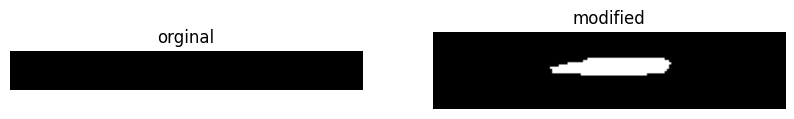

In [34]:
data_to_show = {
    'orginal' : normalize_volume(load_patient(data_folder,chosen_patient)['anatomy'][:, :, 12]),
    'modified' : shifted_data[:,:,9],
}
show_transformation(data_to_show)

THERE IS NO PADDING!!!!

In [35]:
step = 'raw'

for patient in patients:

    data = file_manager.load_file(step, patient)
    center = find_centroid_non_weighted(data['anatomy'])
    for channel in data:
        data[channel] = center_crop_shift(data[channel],center,new_size)
    
    file_manager.save_file('cropped',patient,data)
    

In [36]:
folder_shower(file_manager)
folder_shower(file_manager,step = 'cropped')

interactive(children=(Dropdown(description='Patient:', options=('001', '003', '004', '005', '007', '008', '011…

interactive(children=(Dropdown(description='Patient:', options=('001', '003', '004', '005', '007', '008', '011…